In [ ]:
import os
import json
import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
def generate_toy_dataset(n_samples=400):
    subjects = ["I", "you", "we", "they", "he", "she"]
    verbs = ["am", "are", "feel"]
    emotions = {
        "happy": "🙂",
        "sad": "😢",
        "angry": "😡",
        "tired": "😴",
        "excited": "🤩",
        "confused": "😕"
    }
    actions = {
        "love": "❤️",
        "like": "👍",
        "hate": "💔",
        "learn": "📚",
        "build": "🛠️",
        "see": "👀"
    }
    objects_ = {
        "music": "🎵",
        "food": "🍔",
        "python": "🐍",
        "machine learning": "🤖",
        "books": "📖",
        "flowers": "🌸"
    }
    modifiers = {
        "very": "🔥",
        "really": "✨",
        "not": "🚫"
    }

    pairs = []

    # Emotion sentences
    for s in subjects:
        for v in verbs:
            for e, emo in emotions.items():
                src = f"{s} {v} {e}"
                tgt = f"{emo} 🙋"
                pairs.append((src, tgt))

    # Action sentences
    for s in subjects:
        for a, aemo in actions.items():
            for o, oemo in objects_.items():
                src = f"{s} {a} {o}"
                tgt = f"{aemo} {oemo} 🙋"
                pairs.append((src, tgt))

    # Modified expressions
    for mod, memoji in modifiers.items():
        for e, emo in emotions.items():
            src = f"{mod} {e}"
            tgt = f"{memoji} {emo}"
            pairs.append((src, tgt))

    random.shuffle(pairs)
    return pairs[:n_samples]

pairs = generate_toy_dataset(500)
print(pairs[:10])

[('you love music', '❤️ 🎵 🙋'), ('you hate python', '💔 🐍 🙋'), ('we feel confused', '😕 🙋'), ('we like food', '👍 🍔 🙋'), ('she love machine learning', '❤️ 🤖 🙋'), ('he am happy', '🙂 🙋'), ('they see music', '👀 🎵 🙋'), ('she like books', '👍 📖 🙋'), ('they hate music', '💔 🎵 🙋'), ('not happy', '🚫 🙂')]


In [ ]:
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

class Vocab:
    def __init__(self, tokenized_texts, min_freq=1):
        counter = Counter()
        for tokens in tokenized_texts:
            counter.update(tokens)

        self.itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
        for tok, freq in counter.items():
            if freq >= min_freq and tok not in self.itos:
                self.itos.append(tok)

        self.stoi = {tok: idx for idx, tok in enumerate(self.itos)}
        self.pad_idx = self.stoi[PAD_TOKEN]
        self.sos_idx = self.stoi[SOS_TOKEN]
        self.eos_idx = self.stoi[EOS_TOKEN]
        self.unk_idx = self.stoi[UNK_TOKEN]

    def encode(self, tokens):
        return [self.stoi.get(tok, self.unk_idx) for tok in tokens]

    def decode(self, ids):
        tokens = []
        for i in ids:
            tok = self.itos[i]
            if tok == EOS_TOKEN:
                break
            if tok not in [PAD_TOKEN, SOS_TOKEN]:
                tokens.append(tok)
        return tokens

    def __len__(self):
        return len(self.itos)

In [ ]:
class DataProcessor:
    def __init__(self, pairs, max_len=20):
        self.pairs = pairs
        self.max_len = max_len

        self.src_tokenized = [self.tokenize(src) for src, _ in pairs]
        self.tgt_tokenized = [self.tokenize(tgt) for _, tgt in pairs]

        self.src_vocab = Vocab(self.src_tokenized)
        self.tgt_vocab = Vocab(self.tgt_tokenized)

    def tokenize(self, text):
        return text.strip().split()

    def numericalize_pair(self, src, tgt):
        src_tokens = self.tokenize(src)[:self.max_len-1]
        tgt_tokens = self.tokenize(tgt)[:self.max_len-1]

        src_ids = [self.src_vocab.sos_idx] + self.src_vocab.encode(src_tokens) + [self.src_vocab.eos_idx]
        tgt_ids = [self.tgt_vocab.sos_idx] + self.tgt_vocab.encode(tgt_tokens) + [self.tgt_vocab.eos_idx]
        return src_ids, tgt_ids

    def create_embeddings(self, embedding_dim=256):
        src_emb = nn.Embedding(len(self.src_vocab), embedding_dim, padding_idx=self.src_vocab.pad_idx)
        tgt_emb = nn.Embedding(len(self.tgt_vocab), embedding_dim, padding_idx=self.tgt_vocab.pad_idx)
        return src_emb, tgt_emb

    def get_length_stats(self):
        src_lens = [len(x) for x in self.src_tokenized]
        tgt_lens = [len(x) for x in self.tgt_tokenized]
        return src_lens, tgt_lens

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, processor):
        self.pairs = pairs
        self.processor = processor

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids, tgt_ids = self.processor.numericalize_pair(src, tgt)
        return torch.tensor(src_ids), torch.tensor(tgt_ids), src, tgt

In [ ]:
def collate_fn(batch, src_pad_idx, tgt_pad_idx):
    src_seqs, tgt_seqs, src_texts, tgt_texts = zip(*batch)

    src_lens = [len(x) for x in src_seqs]
    tgt_lens = [len(x) for x in tgt_seqs]

    max_src = max(src_lens)
    max_tgt = max(tgt_lens)

    padded_src = torch.full((len(batch), max_src), src_pad_idx, dtype=torch.long)
    padded_tgt = torch.full((len(batch), max_tgt), tgt_pad_idx, dtype=torch.long)

    for i, seq in enumerate(src_seqs):
        padded_src[i, :len(seq)] = seq

    for i, seq in enumerate(tgt_seqs):
        padded_tgt[i, :len(seq)] = seq

    src_mask = (padded_src != src_pad_idx)
    tgt_mask = (padded_tgt != tgt_pad_idx)

    return padded_src, padded_tgt, src_mask, tgt_mask, src_texts, tgt_texts

In [ ]:
random.shuffle(pairs)
n = len(pairs)
train_pairs = pairs[:int(0.8*n)]
val_pairs = pairs[int(0.8*n):int(0.9*n)]
test_pairs = pairs[int(0.9*n):]

processor = DataProcessor(train_pairs, max_len=20)

train_ds = TranslationDataset(train_pairs, processor)
val_ds = TranslationDataset(val_pairs, processor)
test_ds = TranslationDataset(test_pairs, processor)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda b: collate_fn(b, processor.src_vocab.pad_idx, processor.tgt_vocab.pad_idx)
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    collate_fn=lambda b: collate_fn(b, processor.src_vocab.pad_idx, processor.tgt_vocab.pad_idx)
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    collate_fn=lambda b: collate_fn(b, processor.src_vocab.pad_idx, processor.tgt_vocab.pad_idx)
)

In [ ]:
print("Source vocab size:", len(processor.src_vocab))
print("Target vocab size:", len(processor.tgt_vocab))

Source vocab size: 35
Target vocab size: 26


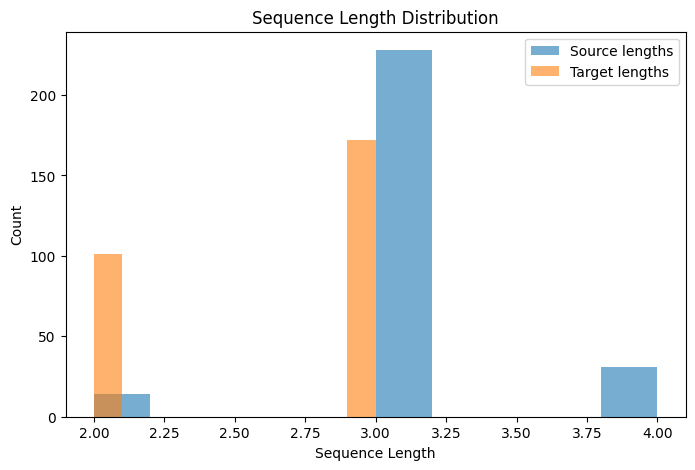

In [ ]:
src_lens, tgt_lens = processor.get_length_stats()

plt.figure(figsize=(8,5))
plt.hist(src_lens, alpha=0.6, label='Source lengths')
plt.hist(tgt_lens, alpha=0.6, label='Target lengths')
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.title("Sequence Length Distribution")
plt.legend()
plt.show()

In [ ]:
for i in range(10):
    src, tgt = train_pairs[i]
    print(f"Raw SRC: {src}")
    print(f"Tokens SRC: {processor.tokenize(src)}")
    print(f"Raw TGT: {tgt}")
    print(f"Tokens TGT: {processor.tokenize(tgt)}")
    print("-"*50)

Raw SRC: I hate flowers
Tokens SRC: ['I', 'hate', 'flowers']
Raw TGT: 💔 🌸 🙋
Tokens TGT: ['💔', '🌸', '🙋']
--------------------------------------------------
Raw SRC: really confused
Tokens SRC: ['really', 'confused']
Raw TGT: ✨ 😕
Tokens TGT: ['✨', '😕']
--------------------------------------------------
Raw SRC: you are confused
Tokens SRC: ['you', 'are', 'confused']
Raw TGT: 😕 🙋
Tokens TGT: ['😕', '🙋']
--------------------------------------------------
Raw SRC: they learn python
Tokens SRC: ['they', 'learn', 'python']
Raw TGT: 📚 🐍 🙋
Tokens TGT: ['📚', '🐍', '🙋']
--------------------------------------------------
Raw SRC: really happy
Tokens SRC: ['really', 'happy']
Raw TGT: ✨ 🙂
Tokens TGT: ['✨', '🙂']
--------------------------------------------------
Raw SRC: we like machine learning
Tokens SRC: ['we', 'like', 'machine', 'learning']
Raw TGT: 👍 🤖 🙋
Tokens TGT: ['👍', '🤖', '🙋']
--------------------------------------------------
Raw SRC: she am angry
Tokens SRC: ['she', 'am', 'angry']
Raw TGT: 

In [ ]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W2 = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, mask=None):
        # decoder_hidden: (batch, hidden_dim)
        # encoder_outputs: (batch, src_len, hidden_dim)

        dec = self.W1(decoder_hidden).unsqueeze(1)           # (batch, 1, hidden_dim)
        enc = self.W2(encoder_outputs)                       # (batch, src_len, hidden_dim)

        scores = self.v(torch.tanh(dec + enc)).squeeze(-1)  # (batch, src_len)

        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)

        attn_weights = torch.softmax(scores, dim=1)         # (batch, src_len)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        # context: (batch, hidden_dim)

        return context, attn_weights

In [ ]:
class LuongAttention(nn.Module):
    def __init__(self, hidden_dim, score_type='dot'):
        super().__init__()
        self.score_type = score_type

        if score_type == 'general':
            self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)
        elif score_type == 'concat':
            self.W = nn.Linear(2 * hidden_dim, hidden_dim)
            self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, mask=None):
        # decoder_hidden: (batch, hidden_dim)
        # encoder_outputs: (batch, src_len, hidden_dim)

        if self.score_type == 'dot':
            scores = torch.bmm(encoder_outputs, decoder_hidden.unsqueeze(2)).squeeze(2)

        elif self.score_type == 'general':
            transformed = self.W(encoder_outputs)
            scores = torch.bmm(transformed, decoder_hidden.unsqueeze(2)).squeeze(2)

        elif self.score_type == 'concat':
            batch_size, src_len, hidden_dim = encoder_outputs.size()
            dec = decoder_hidden.unsqueeze(1).repeat(1, src_len, 1)
            concat = torch.cat([dec, encoder_outputs], dim=-1)
            scores = self.v(torch.tanh(self.W(concat))).squeeze(-1)

        else:
            raise ValueError("Invalid score_type")

        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)

        attn_weights = torch.softmax(scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)

        return context, attn_weights

In [ ]:
class BaselineSeq2Seq(nn.Module):
    def __init__(self, vocab_src, vocab_tgt, embedding_dim, hidden_dim, num_layers=2, dropout=0.3):
        super().__init__()

        self.src_embed = nn.Embedding(vocab_src, embedding_dim, padding_idx=0)
        self.tgt_embed = nn.Embedding(vocab_tgt, embedding_dim, padding_idx=0)

        self.encoder = nn.LSTM(
            embedding_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=False
        )

        self.decoder = nn.LSTM(
            embedding_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc_out = nn.Linear(hidden_dim, vocab_tgt)

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.size()
        vocab_size = self.fc_out.out_features

        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(src.device)

        src_emb = self.src_embed(src)
        _, (hidden, cell) = self.encoder(src_emb)

        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            input_emb = self.tgt_embed(input_token).unsqueeze(1)
            output, (hidden, cell) = self.decoder(input_emb, (hidden, cell))
            pred = self.fc_out(output.squeeze(1))
            outputs[:, t] = pred

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = pred.argmax(1)
            input_token = tgt[:, t] if teacher_force else top1

        return outputs

In [ ]:
class AttentionSeq2Seq(nn.Module):
    def __init__(self, vocab_src, vocab_tgt, embedding_dim, hidden_dim,
                 attention_type='bahdanau', num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()

        self.pad_idx = pad_idx
        self.hidden_dim = hidden_dim
        self.enc_out_dim = hidden_dim * 2
        self.num_layers = num_layers

        self.src_embed = nn.Embedding(vocab_src, embedding_dim, padding_idx=pad_idx)
        self.tgt_embed = nn.Embedding(vocab_tgt, embedding_dim, padding_idx=pad_idx)

        self.encoder = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.decoder = nn.LSTM(
            embedding_dim + self.enc_out_dim,
            self.enc_out_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        if attention_type == 'bahdanau':
            self.attention = BahdanauAttention(self.enc_out_dim)
        elif attention_type == 'luong':
            self.attention = LuongAttention(self.enc_out_dim, score_type='dot')
        elif attention_type == 'luong_general':
            self.attention = LuongAttention(self.enc_out_dim, score_type='general')
        else:
            raise ValueError("Invalid attention_type")

        self.output_projection = nn.Linear(self.enc_out_dim, vocab_tgt)
        self.attention_type = attention_type

    def _merge_bidir_hidden(self, hidden):
        # hidden: (num_layers*2, batch, hidden_dim)
        hidden = hidden.view(self.num_layers, 2, hidden.size(1), hidden.size(2))
        hidden = torch.cat([hidden[:, 0], hidden[:, 1]], dim=2)
        return hidden  # (num_layers, batch, hidden_dim*2)

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.size()
        vocab_size = self.output_projection.out_features

        src_mask = (src != self.pad_idx)

        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(src.device)
        all_attn = []

        src_emb = self.src_embed(src)
        encoder_outputs, (hidden, cell) = self.encoder(src_emb)

        hidden = self._merge_bidir_hidden(hidden)
        cell = self._merge_bidir_hidden(cell)

        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            decoder_hidden = hidden[-1]  # top layer hidden state: (batch, hidden_dim*2)

            context, attn_weights = self.attention(decoder_hidden, encoder_outputs, src_mask)
            all_attn.append(attn_weights.unsqueeze(1))

            input_emb = self.tgt_embed(input_token)
            decoder_input = torch.cat([input_emb, context], dim=1).unsqueeze(1)

            decoder_output, (hidden, cell) = self.decoder(decoder_input, (hidden, cell))
            pred = self.output_projection(decoder_output.squeeze(1))

            outputs[:, t] = pred

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = pred.argmax(1)
            input_token = tgt[:, t] if teacher_force else top1

        if len(all_attn) > 0:
            all_attn = torch.cat(all_attn, dim=1)
        else:
            all_attn = None

        return outputs, all_attn

    def translate(self, src, sos_idx, eos_idx, max_len=50):
        self.eval()
        with torch.no_grad():
            src_mask = (src != self.pad_idx)

            src_emb = self.src_embed(src)
            encoder_outputs, (hidden, cell) = self.encoder(src_emb)

            hidden = self._merge_bidir_hidden(hidden)
            cell = self._merge_bidir_hidden(cell)

            input_token = torch.tensor([sos_idx] * src.size(0), device=src.device)
            predictions = [[sos_idx] for _ in range(src.size(0))]
            attention_maps = []

            for _ in range(max_len):
                decoder_hidden = hidden[-1]
                context, attn_weights = self.attention(decoder_hidden, encoder_outputs, src_mask)
                attention_maps.append(attn_weights.unsqueeze(1))

                input_emb = self.tgt_embed(input_token)
                decoder_input = torch.cat([input_emb, context], dim=1).unsqueeze(1)

                decoder_output, (hidden, cell) = self.decoder(decoder_input, (hidden, cell))
                pred = self.output_projection(decoder_output.squeeze(1))
                top1 = pred.argmax(1)

                input_token = top1
                for i in range(src.size(0)):
                    predictions[i].append(top1[i].item())

            if len(attention_maps) > 0:
                attention_maps = torch.cat(attention_maps, dim=1)
            else:
                attention_maps = None

            return predictions, attention_maps

In [ ]:
def compute_loss(outputs, tgt, pad_idx):
    # outputs: (batch, tgt_len, vocab)
    # tgt: (batch, tgt_len)
    vocab_size = outputs.size(-1)

    outputs = outputs[:, 1:].reshape(-1, vocab_size)
    tgt = tgt[:, 1:].reshape(-1)

    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
    return criterion(outputs, tgt)

In [ ]:
def train_one_epoch(model, loader, optimizer, pad_idx, clip=1.0, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0

    for src, tgt, _, _, _, _ in loader:
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()

        if isinstance(model, AttentionSeq2Seq):
            outputs, _ = model(src, tgt, teacher_forcing_ratio=teacher_forcing_ratio)
        else:
            outputs = model(src, tgt, teacher_forcing_ratio=teacher_forcing_ratio)

        loss = compute_loss(outputs, tgt, pad_idx)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def validate_one_epoch(model, loader, pad_idx):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, tgt, _, _, _, _ in loader:
            src, tgt = src.to(device), tgt.to(device)

            if isinstance(model, AttentionSeq2Seq):
                outputs, _ = model(src, tgt, teacher_forcing_ratio=0.0)
            else:
                outputs = model(src, tgt, teacher_forcing_ratio=0.0)

            loss = compute_loss(outputs, tgt, pad_idx)
            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001,
                pad_idx=0, checkpoint_path="model.pt", patience=5):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    best_val = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        teacher_forcing_ratio = max(0.2, 1.0 - epoch * 0.05)

        start = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, pad_idx, teacher_forcing_ratio=teacher_forcing_ratio)
        val_loss = validate_one_epoch(model, val_loader, pad_idx)
        end = time.time()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {end-start:.2f}s")

        if val_loss < best_val:
            best_val = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(torch.load(checkpoint_path))
    return train_losses, val_losses

In [ ]:
def decode_prediction(pred_ids, vocab):
    return vocab.decode(pred_ids)

In [ ]:
def evaluate_model(model, loader, processor):
    model.eval()
    references = []
    hypotheses = []

    exact_match = 0
    total = 0

    total_loss = 0
    total_inference_time = 0
    total_sentences = 0

    pad_idx = processor.tgt_vocab.pad_idx
    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

    with torch.no_grad():
        for src, tgt, _, _, src_texts, tgt_texts in loader:
            src, tgt = src.to(device), tgt.to(device)

            start = time.time()
            if isinstance(model, AttentionSeq2Seq):
                pred_ids, _ = model.translate(src, processor.tgt_vocab.sos_idx, processor.tgt_vocab.eos_idx, max_len=tgt.size(1))
                outputs, _ = model(src, tgt, teacher_forcing_ratio=0.0)
            else:
                outputs = model(src, tgt, teacher_forcing_ratio=0.0)
                pred_ids = outputs.argmax(-1).tolist()
            end = time.time()

            total_inference_time += (end - start)
            total_sentences += src.size(0)

            vocab_size = outputs.size(-1)
            out_flat = outputs[:, 1:].reshape(-1, vocab_size)
            tgt_flat = tgt[:, 1:].reshape(-1)
            loss = criterion(out_flat, tgt_flat)
            total_loss += loss.item()

            for i in range(len(pred_ids)):
                pred_tokens = decode_prediction(pred_ids[i], processor.tgt_vocab)
                gold_ids = tgt[i].tolist()
                gold_tokens = processor.tgt_vocab.decode(gold_ids)

                references.append([gold_tokens])
                hypotheses.append(pred_tokens)

                if pred_tokens == gold_tokens:
                    exact_match += 1
                total += 1

    bleu = corpus_bleu(references, hypotheses, smoothing_function=SmoothingFunction().method1)
    exact_acc = exact_match / total
    avg_loss = total_loss / len(loader)
    perplexity = math.exp(avg_loss)
    avg_inference_ms = (total_inference_time / total_sentences) * 1000

    return {
        "BLEU": bleu,
        "Exact_Match": exact_acc,
        "Perplexity": perplexity,
        "Inference_ms_per_sentence": avg_inference_ms
    }

In [ ]:
def get_num_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
def get_gpu_memory_gb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024**3)
    return 0.0

In [ ]:
def benchmark_attention(attention_module, hidden_dim=256, seq_lengths=[10,50,100,200], batch_size=32, runs=100):
    attention_module = attention_module.to(device)
    results = {}

    for S in seq_lengths:
        decoder_hidden = torch.randn(batch_size, hidden_dim, device=device)
        encoder_outputs = torch.randn(batch_size, S, hidden_dim, device=device)
        mask = torch.ones(batch_size, S, dtype=torch.bool, device=device)

        # warmup
        for _ in range(10):
            _ = attention_module(decoder_hidden, encoder_outputs, mask)

        torch.cuda.synchronize() if torch.cuda.is_available() else None
        start = time.time()

        for _ in range(runs):
            _ = attention_module(decoder_hidden, encoder_outputs, mask)

        torch.cuda.synchronize() if torch.cuda.is_available() else None
        end = time.time()

        results[S] = end - start

    return results

In [ ]:
bahdanau_bench = benchmark_attention(BahdanauAttention(256), hidden_dim=256)
luong_dot_bench = benchmark_attention(LuongAttention(256, 'dot'), hidden_dim=256)
luong_general_bench = benchmark_attention(LuongAttention(256, 'general'), hidden_dim=256)

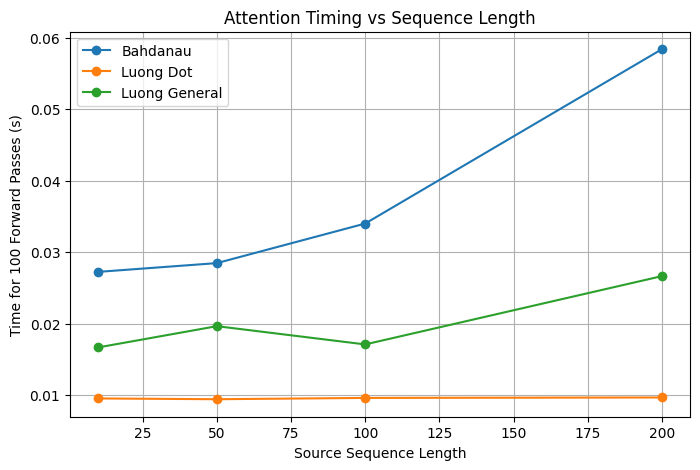

In [ ]:
seqs = list(bahdanau_bench.keys())

plt.figure(figsize=(8,5))
plt.plot(seqs, [bahdanau_bench[s] for s in seqs], marker='o', label='Bahdanau')
plt.plot(seqs, [luong_dot_bench[s] for s in seqs], marker='o', label='Luong Dot')
plt.plot(seqs, [luong_general_bench[s] for s in seqs], marker='o', label='Luong General')
plt.xlabel("Source Sequence Length")
plt.ylabel("Time for 100 Forward Passes (s)")
plt.title("Attention Timing vs Sequence Length")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def visualize_attention(model, processor, sentence):
    model.eval()
    tokens = processor.tokenize(sentence)
    src_ids = [processor.src_vocab.sos_idx] + processor.src_vocab.encode(tokens) + [processor.src_vocab.eos_idx]
    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_ids, attn = model.translate(
            src_tensor,
            processor.tgt_vocab.sos_idx,
            processor.tgt_vocab.eos_idx,
            max_len=10
        )

    pred_tokens = processor.tgt_vocab.decode(pred_ids[0])

    if attn is not None:
        attn_map = attn[0].cpu().numpy()[:len(pred_tokens), :len(src_ids)]

        plt.figure(figsize=(8,5))
        plt.imshow(attn_map, aspect='auto', cmap='viridis')
        plt.colorbar()
        plt.xticks(range(len(src_ids)), [SOS_TOKEN] + tokens + [EOS_TOKEN], rotation=45)
        plt.yticks(range(len(pred_tokens)), pred_tokens)
        plt.xlabel("Source Tokens")
        plt.ylabel("Target Tokens")
        plt.title(f"Attention Heatmap ({model.attention_type})")
        plt.tight_layout()
        plt.show()

    print("Input:", sentence)
    print("Prediction:", " ".join(pred_tokens))

In [ ]:
embedding_dim = 128
hidden_dim = 128
epochs = 20

baseline_model = BaselineSeq2Seq(
    len(processor.src_vocab), len(processor.tgt_vocab),
    embedding_dim, hidden_dim
).to(device)

bahdanau_model = AttentionSeq2Seq(
    len(processor.src_vocab), len(processor.tgt_vocab),
    embedding_dim, hidden_dim,
    attention_type='bahdanau',
    pad_idx=processor.src_vocab.pad_idx
).to(device)

luong_dot_model = AttentionSeq2Seq(
    len(processor.src_vocab), len(processor.tgt_vocab),
    embedding_dim, hidden_dim,
    attention_type='luong',
    pad_idx=processor.src_vocab.pad_idx
).to(device)

luong_general_model = AttentionSeq2Seq(
    len(processor.src_vocab), len(processor.tgt_vocab),
    embedding_dim, hidden_dim,
    attention_type='luong_general',
    pad_idx=processor.src_vocab.pad_idx
).to(device)

In [ ]:
baseline_train, baseline_val = train_model(
    baseline_model, train_loader, val_loader,
    epochs=epochs, pad_idx=processor.tgt_vocab.pad_idx,
    checkpoint_path="baseline.pt"
)

bahdanau_train, bahdanau_val = train_model(
    bahdanau_model, train_loader, val_loader,
    epochs=epochs, pad_idx=processor.tgt_vocab.pad_idx,
    checkpoint_path="bahdanau.pt"
)

luong_dot_train, luong_dot_val = train_model(
    luong_dot_model, train_loader, val_loader,
    epochs=epochs, pad_idx=processor.tgt_vocab.pad_idx,
    checkpoint_path="luong_dot.pt"
)

luong_general_train, luong_general_val = train_model(
    luong_general_model, train_loader, val_loader,
    epochs=epochs, pad_idx=processor.tgt_vocab.pad_idx,
    checkpoint_path="luong_general.pt"
)

Epoch 1/20 | Train Loss: 3.0942 | Val Loss: 2.7734 | Time: 0.77s
Epoch 2/20 | Train Loss: 2.2731 | Val Loss: 2.0653 | Time: 0.09s
Epoch 3/20 | Train Loss: 1.8170 | Val Loss: 1.9481 | Time: 0.11s
Epoch 4/20 | Train Loss: 1.5929 | Val Loss: 1.5509 | Time: 0.14s
Epoch 5/20 | Train Loss: 1.3645 | Val Loss: 1.4278 | Time: 0.14s
Epoch 6/20 | Train Loss: 1.1605 | Val Loss: 1.0581 | Time: 0.14s
Epoch 7/20 | Train Loss: 0.9150 | Val Loss: 0.7542 | Time: 0.14s
Epoch 8/20 | Train Loss: 0.7223 | Val Loss: 0.5540 | Time: 0.14s
Epoch 9/20 | Train Loss: 0.5514 | Val Loss: 0.5994 | Time: 0.14s
Epoch 10/20 | Train Loss: 0.4069 | Val Loss: 0.3182 | Time: 0.15s
Epoch 11/20 | Train Loss: 0.2987 | Val Loss: 0.2321 | Time: 0.15s
Epoch 12/20 | Train Loss: 0.2215 | Val Loss: 0.1813 | Time: 0.14s
Epoch 13/20 | Train Loss: 0.1691 | Val Loss: 0.1423 | Time: 0.14s
Epoch 14/20 | Train Loss: 0.1440 | Val Loss: 0.1099 | Time: 0.15s
Epoch 15/20 | Train Loss: 0.1117 | Val Loss: 0.0981 | Time: 0.15s
Epoch 16/20 | Train

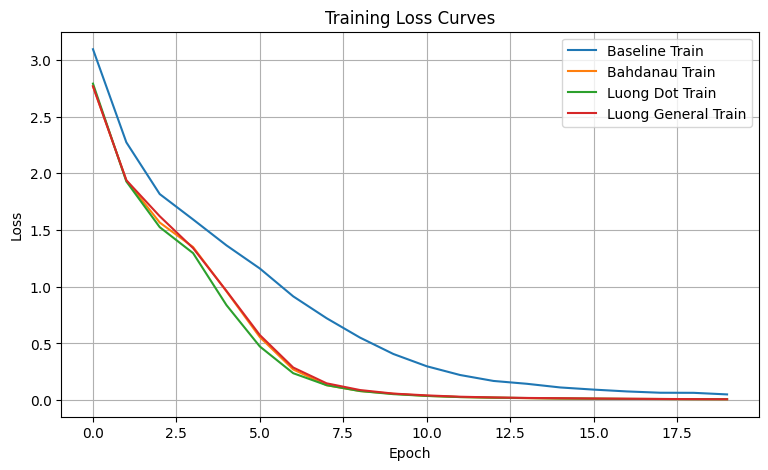

In [ ]:
plt.figure(figsize=(9,5))
plt.plot(baseline_train, label='Baseline Train')
plt.plot(bahdanau_train, label='Bahdanau Train')
plt.plot(luong_dot_train, label='Luong Dot Train')
plt.plot(luong_general_train, label='Luong General Train')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

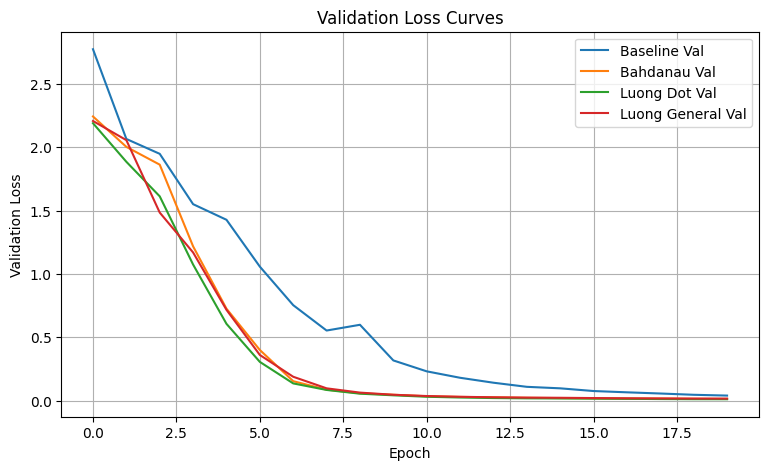

In [ ]:
plt.figure(figsize=(9,5))
plt.plot(baseline_val, label='Baseline Val')
plt.plot(bahdanau_val, label='Bahdanau Val')
plt.plot(luong_dot_val, label='Luong Dot Val')
plt.plot(luong_general_val, label='Luong General Val')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
results = {}

for name, model in [
    ("Baseline", baseline_model),
    ("Bahdanau", bahdanau_model),
    ("Luong_dot", luong_dot_model),
    ("Luong_general", luong_general_model)
]:
    metrics = evaluate_model(model, test_loader, processor)
    metrics["#Parameters"] = get_num_params(model)
    metrics["Memory_Usage_GB"] = get_gpu_memory_gb()
    results[name] = metrics

for k, v in results.items():
    print(k, v)

Baseline {'BLEU': 0.2005207813849661, 'Exact_Match': 0.9428571428571428, 'Perplexity': 1.0670773945018175, 'Inference_ms_per_sentence': 0.1716205051967076, '#Parameters': 539546, 'Memory_Usage_GB': 0.1354236602783203}
Bahdanau {'BLEU': 0.2020062220182669, 'Exact_Match': 0.9714285714285714, 'Perplexity': 1.0161167994626628, 'Inference_ms_per_sentence': 0.5632059914725167, '#Parameters': 1989018, 'Memory_Usage_GB': 0.1354236602783203}
Luong_dot {'BLEU': 0.203479565461845, 'Exact_Match': 1.0, 'Perplexity': 1.0150324262352544, 'Inference_ms_per_sentence': 0.4585742950439453, '#Parameters': 1857690, 'Memory_Usage_GB': 0.1354236602783203}
Luong_general {'BLEU': 0.203479565461845, 'Exact_Match': 1.0, 'Perplexity': 1.0181947937554845, 'Inference_ms_per_sentence': 0.5036490304129465, '#Parameters': 1923226, 'Memory_Usage_GB': 0.1354236602783203}


In [ ]:
import pandas as pd
df = pd.DataFrame(results).T
print(df)

                   BLEU  Exact_Match  Perplexity  Inference_ms_per_sentence  \
Baseline       0.200521     0.942857    1.067077                   0.171621   
Bahdanau       0.202006     0.971429    1.016117                   0.563206   
Luong_dot      0.203480     1.000000    1.015032                   0.458574   
Luong_general  0.203480     1.000000    1.018195                   0.503649   

               #Parameters  Memory_Usage_GB  
Baseline          539546.0         0.135424  
Bahdanau         1989018.0         0.135424  
Luong_dot        1857690.0         0.135424  
Luong_general    1923226.0         0.135424  


Questions:
---

1. Why Luong scales better?


Luong dot uses only dot products, so it is simpler.
It avoids the small neural network used in Bahdanau scoring.
It can be implemented efficiently using matrix multiplication on GPU.
Therefore, as sequence length increases, Luong dot becomes noticeably faster.

2. Does Bahdanau produce sharper attention distributions?

Usually yes, often it does.
Reason:

Bahdanau learns a flexible alignment function
it can model non-linear relationships
this sometimes leads to more focused attention on one source token

But this is not guaranteed for every sentence.

3. Does Luong sometimes attend to multiple positions equally?

Yes, especially Luong dot can do that.

Reason:

similarity is based directly on vector dot product
if two encoder positions are similarly aligned with the decoder state, weights may be spread across both

So Luong attention can look more diffused.

4. Examples where one fails and the other succeeds

Bahdanau may perform better on longer or more ambiguous sequences because the scoring function is more expressive.
Luong dot may work well on short, direct mappings because it is simpler and faster.
Baseline fails when source-target alignment is important because there is no access to encoder states at each step.

5. Why Transformers moved to multiplicative attention

Transformers moved toward multiplicative attention because:

dot-product attention is computationally efficient
it is highly parallelizable on GPUs
it works very well with matrix multiplication
no recurrent dependency is needed
self-attention allows every token to directly interact with every other token
scaled dot-product attention is simple and fast for large datasets

So although Bahdanau is expressive, multiplicative attention is better for speed, scalability, and hardware efficiency.